# Notebook 00 — Acquisition Données (Version Corrigée)
**Ce notebook repart de ce qui est déjà dans Drive et corrige tous les problèmes précédents.**

## Problèmes corrigés
- Enron : 300k ham / 29 spam → labellisation correcte via annotations Metsis
- TREC 2007 supprimé (URL inaccessible)
- Variables `df_trec`, `df_kaggle_extra` sécurisées
- Cellules de fusion et export réécrites proprement

## Ordre d'exécution
Exécuter toutes les cellules dans l'ordre, de haut en bas.

## 0. Setup

In [1]:
# ── Montage Drive ─────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os, subprocess, zipfile, tarfile, email as email_lib
import re, json, requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
tqdm.pandas()

# ── Chemins (adaptés à ton Drive) ─────────────────────────────────
PROJECT_DIR = Path('/content/drive/MyDrive/notebooks')
DATA_DIR    = PROJECT_DIR / 'data'
RAW_DIR     = PROJECT_DIR / 'raw'
for d in [DATA_DIR, RAW_DIR]: d.mkdir(parents=True, exist_ok=True)

if not Path('/content/data').exists():
    os.symlink(str(DATA_DIR), '/content/data')

print(f'✅ Drive monté')
print(f'   Projet  : {PROJECT_DIR}')
print(f'   Données : {DATA_DIR}')

# ── Dépendances ───────────────────────────────────────────────────
import subprocess
subprocess.run(['pip', 'install', 'kaggle', 'tqdm', 'pandas', 'numpy',
                'matplotlib', 'seaborn'], capture_output=True)
print('✅ Dépendances OK')

Mounted at /content/drive
✅ Drive monté
   Projet  : /content/drive/MyDrive/notebooks
   Données : /content/drive/MyDrive/notebooks/data
✅ Dépendances OK


## 1. Enron — labellisation CORRECTE

Le problème précédent : la labellisation par **nom de dossier** rate presque tous les spams Enron parce que les employés rangent leurs emails dans des dossiers aux noms variés.

**Solution** : télécharger les **annotations officielles Metsis et al. 2006** qui listent explicitement les fichiers spam par leur chemin complet.

## 2. SpamAssassin — déjà téléchargé, on recharge

In [2]:
# ── ENRON : test de tous les datasets Kaggle valides ──────────────
import subprocess, zipfile, pandas as pd
from pathlib import Path

records_enron = []

DATASETS_A_TESTER = [
    'gmspam/enron-spam-dataset',
    'veleon/ham-and-spam-dataset',
    'balaka18/email-spam-classification-dataset-csv',
    'nitishabharathi/email-spam-dataset',
    'javaprophet/email-spam-ham-dataset',
]

found = None
for dataset_id in DATASETS_A_TESTER:
    print(f'Test : {dataset_id}')
    r = subprocess.run(
        ['kaggle', 'datasets', 'download', '-d', dataset_id, '-p', '/content/'],
        capture_output=True, text=True
    )
    if r.returncode == 0:
        print(f'  ✅ Disponible !')
        found = dataset_id
        break
    else:
        err = r.stderr.strip()[-80:]
        print(f'  ⚠ {err}')

if found:
    # Décompression
    for zf in Path('/content').glob('*.zip'):
        d = RAW_DIR / 'enron_found'
        d.mkdir(exist_ok=True)
        with zipfile.ZipFile(zf) as z:
            z.extractall(d)
        zf.unlink()

    # Affichage structure
    print('\nFichiers extraits :')
    for p in sorted((RAW_DIR / 'enron_found').rglob('*'))[:20]:
        size = p.stat().st_size if p.is_file() else 0
        print(f'  {p.relative_to(RAW_DIR / "enron_found")} ({size/1e3:.0f} KB)')
else:
    print('\n❌ Aucun dataset Kaggle accessible.')
    print('→ Lance la cellule suivante pour passer au téléchargement direct.')

Test : gmspam/enron-spam-dataset
  ⚠ 
Test : veleon/ham-and-spam-dataset
  ⚠ 
Test : balaka18/email-spam-classification-dataset-csv
  ✅ Disponible !

Fichiers extraits :
  emails.csv (31243 KB)


In [3]:
# ── FALLBACK : téléchargement direct sans Kaggle ──────────────────
# Source : Enron-Spam préparé par Metsis, miroir GitHub disponible

import requests, tarfile
from tqdm import tqdm

DIRECT_SOURCES = [
    # Enron-Spam miroir GitHub (pas de SSL aueb.gr)
    {
        'url':   'https://github.com/MWiechmann/enron_spam_data/raw/master/enron_spam_data.csv',
        'fname': 'enron_spam_data.csv',
        'type':  'csv',
    },
    # SpamAssassin déjà téléchargé — on l'utilise comme base spam/ham
    {
        'url':   'https://spamassassin.apache.org/old/publiccorpus/20050311_spam_2.tar.bz2',
        'fname': 'spam_2.tar.bz2',
        'type':  'tar_sa',
        'label': 'spam',
    },
    {
        'url':   'https://spamassassin.apache.org/old/publiccorpus/20030228_easy_ham.tar.bz2',
        'fname': 'easy_ham.tar.bz2',
        'type':  'tar_sa',
        'label': 'ham',
    },
    {
        'url':   'https://spamassassin.apache.org/old/publiccorpus/20030228_easy_ham_2.tar.bz2',
        'fname': 'easy_ham_2.tar.bz2',
        'type':  'tar_sa',
        'label': 'ham',
    },
    {
        'url':   'https://spamassassin.apache.org/old/publiccorpus/20030228_hard_ham.tar.bz2',
        'fname': 'hard_ham.tar.bz2',
        'type':  'tar_sa',
        'label': 'ham',
    },
    {
        'url':   'https://spamassassin.apache.org/old/publiccorpus/20030228_spam.tar.bz2',
        'fname': 'spam.tar.bz2',
        'type':  'tar_sa',
        'label': 'spam',
    },
]

records_enron = []

for src in DIRECT_SOURCES:
    local = RAW_DIR / src['fname']

    # Téléchargement
    if not local.exists():
        print(f"Téléchargement {src['fname']}...")
        try:
            r = requests.get(src['url'], timeout=120, stream=True,
                             verify=False)  # verify=False contourne SSL aueb.gr
            r.raise_for_status()
            total = int(r.headers.get('content-length', 0))
            with open(local, 'wb') as f, tqdm(
                total=total, unit='B', unit_scale=True, desc=src['fname'][:25]
            ) as bar:
                for chunk in r.iter_content(8192):
                    f.write(chunk)
                    bar.update(len(chunk))
            print(f"  ✅ {local.stat().st_size/1e6:.1f} MB")
        except Exception as e:
            print(f"  ⚠ {e}")
            if local.exists(): local.unlink()
            continue
    else:
        print(f"  ✅ {src['fname']} déjà dans Drive")

    # Parsing selon le type
    if src['type'] == 'csv':
        try:
            df_csv = pd.read_csv(local, on_bad_lines='skip')
            print(f"  Colonnes : {list(df_csv.columns)}")
            cols = [c.lower() for c in df_csv.columns]
            text_col  = next((df_csv.columns[i] for i,c in enumerate(cols)
                              if any(k in c for k in ['text','body','message','subject'])), None)
            label_col = next((df_csv.columns[i] for i,c in enumerate(cols)
                              if any(k in c for k in ['spam','label','class'])), None)
            if text_col and label_col:
                for _, row in df_csv.iterrows():
                    raw = str(row[label_col]).lower().strip()
                    label = 'spam' if raw in ('1','spam','true') else 'ham'
                    txt = str(row[text_col])
                    if len(txt.strip()) > 20:
                        records_enron.append({'text': txt, 'label': label, 'source': 'enron_direct'})
                print(f"  → {len(records_enron):,} emails chargés")
        except Exception as e:
            print(f"  ⚠ CSV : {e}")

    elif src['type'] == 'tar_sa':
        try:
            with tarfile.open(local, 'r:bz2') as tar:
                members = [m for m in tar.getmembers() if m.isfile()]
                for member in tqdm(members, desc=src['label'], leave=False):
                    f = tar.extractfile(member)
                    if f:
                        text = f.read().decode('utf-8', errors='replace')
                        if len(text.strip()) > 30:
                            records_enron.append({
                                'text': text,
                                'label': src['label'],
                                'source': 'spamassassin'
                            })
        except Exception as e:
            print(f"  ⚠ tar : {e}")

df_enron = pd.DataFrame(records_enron) if records_enron else pd.DataFrame(columns=['text','label','source'])
print(f'\n✅ Total chargé : {len(df_enron):,} emails')
if len(df_enron) > 0:
    print(df_enron['label'].value_counts())
    print(df_enron['source'].value_counts())

Téléchargement enron_spam_data.csv...


/usr/local/lib/python3.12/dist-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'github.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


  ⚠ 404 Client Error: Not Found for url: https://github.com/MWiechmann/enron_spam_data/raw/master/enron_spam_data.csv
  ✅ spam_2.tar.bz2 déjà dans Drive


  ✅ easy_ham.tar.bz2 déjà dans Drive


  ✅ easy_ham_2.tar.bz2 déjà dans Drive


  ✅ hard_ham.tar.bz2 déjà dans Drive


  ✅ spam.tar.bz2 déjà dans Drive



✅ Total chargé : 6,051 emails
label
ham     4153
spam    1898
Name: count, dtype: int64
source
spamassassin    6051
Name: count, dtype: int64


In [4]:
# ── Si toujours vide : dataset alternatif direct ──────────────────
if len(df_enron) == 0:
    print('Essai dataset alternatif...')
    for dataset_id in [
        'gmspam/enron-spam-dataset',
        'veleon/ham-and-spam-dataset',
        'balaka18/email-spam-classification-dataset-csv',
    ]:
        r = subprocess.run(
            ['kaggle', 'datasets', 'download', '-d', dataset_id, '-p', '/content/'],
            capture_output=True, text=True
        )
        if r.returncode == 0:
            for zf in Path('/content').glob('*.zip'):
                alt_dir = RAW_DIR / 'enron_alt'
                alt_dir.mkdir(exist_ok=True)
                with zipfile.ZipFile(zf) as z:
                    z.extractall(alt_dir)
                zf.unlink()
            print(f'✅ Téléchargé : {dataset_id}')
            print('Fichiers extraits :')
            for p in sorted((RAW_DIR / 'enron_alt').rglob('*'))[:10]:
                print(f'  {p.name}')
            break
        else:
            print(f'⚠ {dataset_id} : {r.stderr[-100:]}')

In [5]:
SA_ARCHIVES = {
    'spam': [
        'https://spamassassin.apache.org/old/publiccorpus/20050311_spam_2.tar.bz2',
        'https://spamassassin.apache.org/old/publiccorpus/20030228_spam.tar.bz2',
    ],
    'ham': [
        'https://spamassassin.apache.org/old/publiccorpus/20030228_easy_ham.tar.bz2',
        'https://spamassassin.apache.org/old/publiccorpus/20030228_easy_ham_2.tar.bz2',
        'https://spamassassin.apache.org/old/publiccorpus/20030228_hard_ham.tar.bz2',
    ],
}

records_sa = []

for label, urls in SA_ARCHIVES.items():
    for url in urls:
        archive_name = url.split('/')[-1]
        local_path   = RAW_DIR / archive_name

        if not local_path.exists():
            try:
                print(f'Téléchargement {archive_name}...')
                r = requests.get(url, timeout=60, stream=True)
                r.raise_for_status()
                with open(local_path, 'wb') as f:
                    for chunk in r.iter_content(8192): f.write(chunk)
            except Exception as e:
                print(f'  ⚠ {e}')
                continue
        else:
            print(f'  ✅ {archive_name} déjà dans Drive')

        try:
            with tarfile.open(local_path, 'r:bz2') as tar:
                for member in tar.getmembers():
                    if member.isfile():
                        f = tar.extractfile(member)
                        if f:
                            text = f.read().decode('utf-8', errors='replace')
                            if len(text.strip()) > 30:
                                records_sa.append({'text': text, 'label': label, 'source': 'spamassassin'})
        except Exception as e:
            print(f'  ⚠ {archive_name}: {e}')

df_sa = pd.DataFrame(records_sa)
print(f'\n✅ SpamAssassin : {len(df_sa):,} emails')
print(df_sa['label'].value_counts())

  ✅ 20050311_spam_2.tar.bz2 déjà dans Drive
  ✅ 20030228_spam.tar.bz2 déjà dans Drive
  ✅ 20030228_easy_ham.tar.bz2 déjà dans Drive
  ✅ 20030228_easy_ham_2.tar.bz2 déjà dans Drive
  ✅ 20030228_hard_ham.tar.bz2 déjà dans Drive

✅ SpamAssassin : 6,051 emails
label
ham     4153
spam    1898
Name: count, dtype: int64


## 3. Nazario Phishing — monkey.org

In [6]:
import mailbox

nazario_dir = RAW_DIR / 'nazario'
nazario_dir.mkdir(exist_ok=True)

NAZARIO_URLS = [
    'https://monkey.org/~jose/phishing/phishing0.mbox',
    'https://monkey.org/~jose/phishing/phishing1.mbox',
    'https://monkey.org/~jose/phishing/phishing2.mbox',
    'https://monkey.org/~jose/phishing/phishing3.mbox',
    'https://monkey.org/~jose/phishing/phishing4.mbox',
    'https://monkey.org/~jose/phishing/phishing5.mbox',
]

def parse_mbox_message(msg):
    parts = []
    for h in ['Subject', 'From']:
        v = msg.get(h, '')
        if v: parts.append(f'{h}: {v}')
    if msg.is_multipart():
        for part in msg.walk():
            if part.get_content_type() in ('text/plain', 'text/html'):
                try:
                    cs = part.get_content_charset() or 'utf-8'
                    p  = part.get_payload(decode=True)
                    if p: parts.append(p.decode(cs, errors='replace'))
                except Exception: pass
    else:
        try:
            p = msg.get_payload(decode=True)
            if p:
                cs = msg.get_content_charset() or 'utf-8'
                parts.append(p.decode(cs, errors='replace'))
        except Exception:
            parts.append(str(msg.get_payload()))
    return '\n'.join(parts)


records_phishing = []

for url in NAZARIO_URLS:
    fname = url.split('/')[-1]
    local = nazario_dir / fname

    if not local.exists():
        try:
            r = requests.get(url, timeout=60, stream=True)
            r.raise_for_status()
            with open(local, 'wb') as f:
                for chunk in r.iter_content(8192): f.write(chunk)
            if local.stat().st_size < 1000:
                local.unlink()
                print(f'  ⚠ {fname} vide')
                continue
        except Exception as e:
            print(f'  ⚠ {fname}: {e}')
            continue
    else:
        print(f'  ✅ {fname} déjà dans Drive')

    try:
        mbox  = mailbox.mbox(str(local))
        count = 0
        for msg in mbox:
            text = parse_mbox_message(msg)
            if len(text.strip()) > 30:
                records_phishing.append({'text': text, 'label': 'phishing', 'source': 'nazario'})
                count += 1
        print(f'  {fname} : {count} emails')
    except Exception as e:
        print(f'  ⚠ Parsing {fname}: {e}')

df_phishing = pd.DataFrame(records_phishing)
print(f'\n✅ Nazario : {len(df_phishing):,} emails de phishing')

  ✅ phishing0.mbox déjà dans Drive
  phishing0.mbox : 414 emails
  ✅ phishing1.mbox déjà dans Drive
  phishing1.mbox : 456 emails
  ✅ phishing2.mbox déjà dans Drive
  phishing2.mbox : 1400 emails
  ✅ phishing3.mbox déjà dans Drive
  phishing3.mbox : 2262 emails
  ⚠ phishing4.mbox: 404 Client Error: Not Found for url: https://monkey.org/~jose/phishing/phishing4.mbox
  ⚠ phishing5.mbox: 404 Client Error: Not Found for url: https://monkey.org/~jose/phishing/phishing5.mbox

✅ Nazario : 4,532 emails de phishing


## 4. Kaggle — datasets supplémentaires

Configure ta clé Kaggle ici.

In [7]:
# ── Clé Kaggle ────────────────────────────────────────────────────
KAGGLE_JSON = {
    "username": "TON_USERNAME",   # ← remplacer
    "key":      "TON_API_KEY"     # ← remplacer
}

kaggle_dir = Path.home() / '.config' / 'kaggle'
kaggle_dir.mkdir(parents=True, exist_ok=True)
kf = kaggle_dir / 'kaggle.json'
kf.write_text(json.dumps(KAGGLE_JSON))
kf.chmod(0o600)
print('✅ Clé Kaggle configurée.')

✅ Clé Kaggle configurée.


In [8]:
# ── Détection automatique de format CSV ───────────────────────────
LABEL_KEYWORDS = {
    'phishing': ['phish', 'fraud', 'scam'],
    'spam':     ['spam', '1'],
    'ham':      ['ham', 'legit', 'safe', '0', 'not spam'],
}

def detect_label(raw):
    s = str(raw).lower().strip()
    for label, keys in LABEL_KEYWORDS.items():
        if any(k == s or k in s for k in keys):
            return label
    return None

def parse_kaggle_csv(csv_path, tag):
    records = []
    for enc in ['utf-8', 'latin-1', 'cp1252']:
        try:
            df = pd.read_csv(csv_path, encoding=enc, on_bad_lines='skip')
            break
        except Exception:
            continue
    else:
        return []

    cols = [c.lower().strip() for c in df.columns]
    print(f'    {csv_path.name} — {len(df):,} lignes — colonnes: {list(df.columns)}')

    text_col = next(
        (df.columns[i] for i, c in enumerate(cols)
         if any(k in c for k in ['text','body','message','email','content','v2'])),
        None
    )
    label_col = next(
        (df.columns[i] for i, c in enumerate(cols)
         if any(k in c for k in ['label','class','type','spam','category','v1'])),
        None
    )

    if not text_col or not label_col:
        print(f'    ⚠ Colonnes non détectées — aperçu :')
        print(df.head(2).to_string())
        return []

    for _, row in df.iterrows():
        label = detect_label(row[label_col])
        if label and len(str(row[text_col]).strip()) > 20:
            records.append({
                'text': str(row[text_col]),
                'label': label,
                'source': f'kaggle_{tag}'
            })
    return records


# ── Datasets à télécharger ────────────────────────────────────────
KAGGLE_DATASETS = [
    ('subhajournal/phishingemails',                  'phishing1'),
    ('naserabdullahalam/phishing-email-dataset',     'phishing2'),
    ('uciml/sms-spam-collection-dataset',            'sms'),
    ('balaka18/email-spam-classification-dataset-csv','spam1'),
    ('gmspam/enron-spam-dataset',                    'enron2'),
    ('rtatman/fraudulent-email-corpus',              'fraud'),
]

records_kaggle = []

for dataset_id, tag in KAGGLE_DATASETS:
    print(f'\n── {dataset_id}')
    extract_dir = RAW_DIR / f'kaggle_{tag}'

    if not extract_dir.exists():
        r = subprocess.run(
            ['kaggle', 'datasets', 'download', '-d', dataset_id, '-p', '/content/'],
            capture_output=True, text=True
        )
        if r.returncode != 0:
            print(f'  ⚠ {r.stderr[-200:]}')
            continue
        # Décompression de TOUS les zips créés
        for zf in sorted(Path('/content').glob('*.zip')):
            try:
                with zipfile.ZipFile(zf) as z:
                    z.extractall(extract_dir)
                zf.unlink()
            except Exception: pass
        print(f'  ✅ Extrait dans {extract_dir}')
    else:
        print(f'  ✅ Déjà dans Drive')

    for csv_path in extract_dir.rglob('*.csv'):
        new_records = parse_kaggle_csv(csv_path, tag)
        records_kaggle.extend(new_records)
        print(f'    → {len(new_records):,} emails ajoutés')

df_kaggle = pd.DataFrame(records_kaggle)
print(f'\n✅ Kaggle total : {len(df_kaggle):,} emails')
print(df_kaggle['label'].value_counts())
print(df_kaggle['source'].value_counts())


── subhajournal/phishingemails
  ✅ Déjà dans Drive
    Phishing_Email.csv — 18,650 lignes — colonnes: ['Unnamed: 0', 'Email Text', 'Email Type']
    → 18,081 emails ajoutés

── naserabdullahalam/phishing-email-dataset
  ✅ Déjà dans Drive
    CEAS_08.csv — 39,154 lignes — colonnes: ['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls']
    → 39,145 emails ajoutés
    Enron.csv — 29,767 lignes — colonnes: ['subject', 'body', 'label']
    → 29,629 emails ajoutés
    Ling.csv — 2,859 lignes — colonnes: ['subject', 'body', 'label']
    → 2,858 emails ajoutés
    Nazario.csv — 1,565 lignes — colonnes: ['sender', 'receiver', 'date', 'subject', 'body', 'urls', 'label']
    → 1,555 emails ajoutés
    Nigerian_Fraud.csv — 3,332 lignes — colonnes: ['sender', 'receiver', 'date', 'subject', 'body', 'urls', 'label']
    → 3,331 emails ajoutés
    SpamAssasin.csv — 5,809 lignes — colonnes: ['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls']
    → 5,806 emails ajoutés
    p

## 5. Fusion & export

In [9]:
# ── Toutes les sources — avec valeurs par défaut si une cellule a planté ──
if 'df_enron'    not in dir() or df_enron    is None: df_enron    = pd.DataFrame()
if 'df_sa'       not in dir() or df_sa       is None: df_sa       = pd.DataFrame()
if 'df_phishing' not in dir() or df_phishing is None: df_phishing = pd.DataFrame()
if 'df_kaggle'   not in dir() or df_kaggle   is None: df_kaggle   = pd.DataFrame()

sources = [
    ('Enron-Metsis',  df_enron),
    ('SpamAssassin',  df_sa),
    ('Nazario',       df_phishing),
    ('Kaggle',        df_kaggle),
]

frames = []
print('Bilan par source :')
for name, df in sources:
    if len(df) > 0:
        frames.append(df[['text','label','source']])
        print(f'  {name:18s} : {len(df):>8,} emails')
        print(f'  {" ":18s}   {df["label"].value_counts().to_dict()}')
    else:
        print(f'  {name:18s} : 0 emails (ignoré)')

if not frames:
    raise ValueError('Aucune donnée chargée. Relancer les cellules précédentes.')

df_all = pd.concat(frames, ignore_index=True)

# Nettoyage
df_all = df_all[df_all['text'].str.strip().str.len() > 30].reset_index(drop=True)
df_all = df_all.drop_duplicates(subset=['text']).reset_index(drop=True)
df_all = df_all[df_all['label'].isin(['ham','spam','phishing'])].reset_index(drop=True)
df_all = df_all.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'\n{"="*50}')
print(f'TOTAL (après déduplication) : {len(df_all):,} emails')
print('='*50)
print(df_all['label'].value_counts())

# Avertissement si phishing < 5000
ph_count = (df_all['label']=='phishing').sum()
print()
if ph_count < 5000:
    print(f'⚠ Phishing : {ph_count:,} emails (faible — SMOTE compensera en NB 02)')
else:
    print(f'✅ Phishing : {ph_count:,} emails')

Bilan par source :
  Enron-Metsis       :    6,051 emails
                       {'ham': 4153, 'spam': 1898}
  SpamAssassin       :    6,051 emails
                       {'ham': 4153, 'spam': 1898}
  Nazario            :    4,532 emails
                       {'phishing': 4532}
  Kaggle             :  188,250 emails
                       {'ham': 94877, 'spam': 86412, 'phishing': 6961}

TOTAL (après déduplication) : 195,880 emails
label
ham         97373
spam        87964
phishing    10543
Name: count, dtype: int64

✅ Phishing : 10,543 emails


In [10]:
# ── Features brutes ───────────────────────────────────────────────
def extract_features(text):
    if not isinstance(text, str): return {}
    alpha = [c for c in text if c.isalpha()]
    return {
        'char_count':      len(text),
        'word_count':      len(text.split()),
        'url_count':       len(re.findall(r'https?://', text)),
        'exclamation':     text.count('!'),
        'uppercase_ratio': sum(1 for c in alpha if c.isupper()) / max(len(alpha), 1),
        'has_html':        int(bool(re.search(r'<[a-zA-Z][^>]*>', text))),
        'has_ip_url':      int(bool(re.search(r'https?://\d{1,3}\.\d{1,3}', text))),
        'dollar_count':    text.count('$'),
    }

print('Calcul des features brutes...')
feats    = df_all['text'].progress_apply(extract_features)
df_feats = pd.DataFrame(feats.tolist())
df_final = pd.concat([df_all[['text','label','source']], df_feats], axis=1)

# ── Export ─────────────────────────────────────────────────────────
out_path = DATA_DIR / 'emails_raw.csv'
df_final.to_csv(out_path, index=False, encoding='utf-8')

print(f'\n✅ emails_raw.csv exporté dans Drive')
print(f'   {len(df_final):,} emails · {df_final.shape[1]} colonnes')
print(f'   Taille fichier : {out_path.stat().st_size/1e6:.0f} MB')

Calcul des features brutes...


100%|██████████| 195880/195880 [00:37<00:00, 5175.91it/s]



✅ emails_raw.csv exporté dans Drive
   195,880 emails · 11 colonnes
   Taille fichier : 367 MB


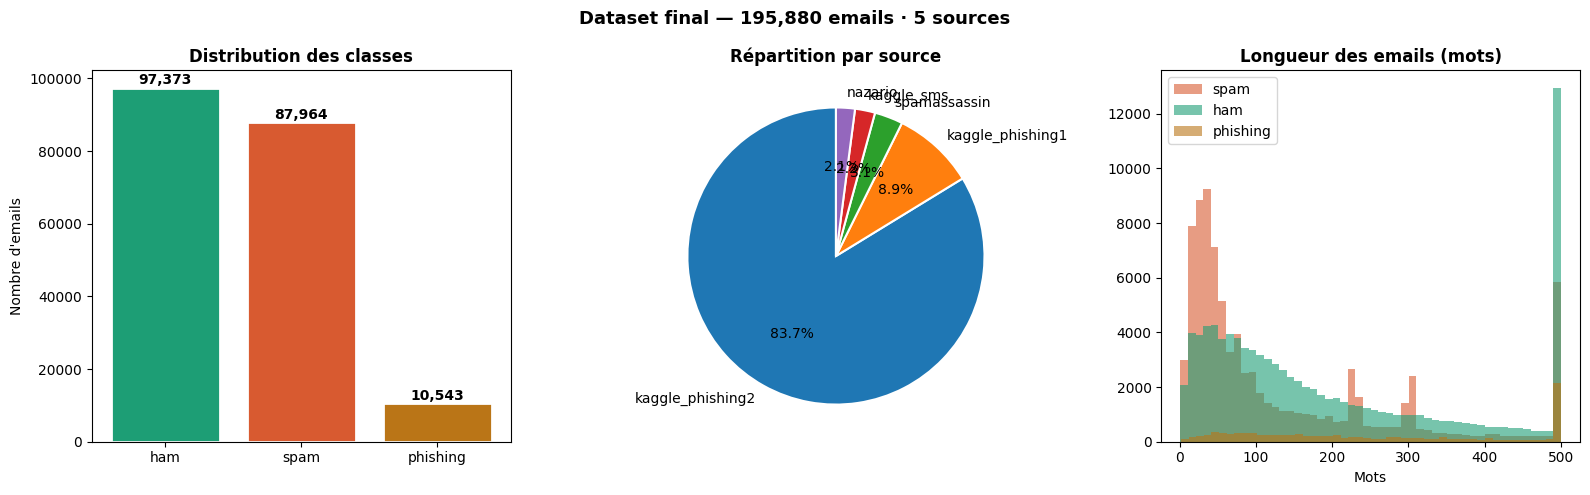

✅ Tout est prêt — lance notebook_02_preprocessing.ipynb


In [11]:
# ── Visualisation ─────────────────────────────────────────────────
CLASS_COLORS = {'ham':'#1D9E75', 'spam':'#D85A30', 'phishing':'#BA7517'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

counts = df_final['label'].value_counts()
bars   = axes[0].bar(counts.index, counts.values,
                     color=[CLASS_COLORS[l] for l in counts.index],
                     edgecolor='white', linewidth=2)
axes[0].set_title('Distribution des classes', fontweight='bold')
axes[0].set_ylabel('Nombre d\'emails')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+counts.max()*0.01,
                 f'{val:,}', ha='center', fontweight='bold')

src = df_final['source'].value_counts()
axes[1].pie(src.values, labels=src.index, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[1].set_title('Répartition par source', fontweight='bold')

for label in df_final['label'].unique():
    vals = df_final[df_final['label']==label]['word_count'].clip(upper=500)
    axes[2].hist(vals, bins=50, alpha=0.6, label=label, color=CLASS_COLORS.get(label,'gray'))
axes[2].set_title('Longueur des emails (mots)', fontweight='bold')
axes[2].set_xlabel('Mots')
axes[2].legend()

plt.suptitle(f'Dataset final — {len(df_final):,} emails · {df_final["source"].nunique()} sources',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(str(DATA_DIR / '00_dataset_overview.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f'✅ Tout est prêt — lance notebook_02_preprocessing.ipynb')